Module 1 — Early Detection (Recurred: Yes/No)

In [52]:
from google.colab import files
uploaded = files.upload()  # A button will appear — click it and select Thyroid_Diff.csv

import pandas as pd
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("✅ Dataset loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Saving Thyroid_Diff.csv to Thyroid_Diff (5).csv
✅ Dataset loaded!
Shape: (383, 17)
Columns: ['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [53]:
print("Columns:", df.columns.tolist())

Columns: ['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']


In [54]:
!pip install xgboost lightgbm shap imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print("✅ All libraries imported!")

✅ All libraries imported!


In [55]:
from google.colab import files
uploaded = files.upload()  # Upload Thyroid_Diff.csv here

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("✅ Dataset loaded!")
print("Shape:", df.shape)
df.head()

Saving Thyroid_Diff.csv to Thyroid_Diff (6).csv
✅ Dataset loaded!
Shape: (383, 17)


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


=== Missing Values ===
Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64

=== Target Distribution ===
Recurred
No     275
Yes    108
Name: count, dtype: int64


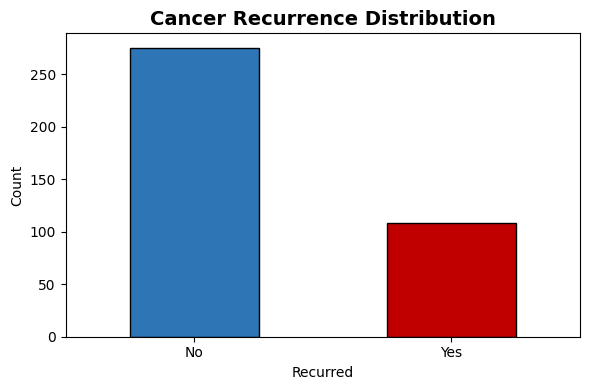

✅ EDA done!


In [56]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Distribution ===")
print(df['Recurred'].value_counts())

# Plot target
plt.figure(figsize=(6,4))
df['Recurred'].value_counts().plot(kind='bar',
    color=['#2E75B6','#C00000'], edgecolor='black')
plt.title('Cancer Recurrence Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Recurred')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()
print("✅ EDA done!")

In [57]:
data = df.copy()

# Encode all categorical columns
le = LabelEncoder()
categorical_cols = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
                    'Thyroid Function', 'Physical Examination', 'Adenopathy',
                    'Pathology', 'Focality', 'Risk', 'T', 'N', 'M',
                    'Stage', 'Response', 'Recurred']

for col in categorical_cols:
    data[col] = le.fit_transform(data[col].astype(str))

print("✅ Encoding done!")
print(data.dtypes)

# Features and target
X = data.drop('Recurred', axis=1)
y = data['Recurred']

# Scale
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

print(f"\nBefore SMOTE: {y.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_res).value_counts().to_dict()}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

print(f"\n✅ Train: {X_train.shape}, Test: {X_test.shape}")

✅ Encoding done!
Age                     int64
Gender                  int64
Smoking                 int64
Hx Smoking              int64
Hx Radiothreapy         int64
Thyroid Function        int64
Physical Examination    int64
Adenopathy              int64
Pathology               int64
Focality                int64
Risk                    int64
T                       int64
N                       int64
M                       int64
Stage                   int64
Response                int64
Recurred                int64
dtype: object

Before SMOTE: {0: 275, 1: 108}
After SMOTE:  {0: 275, 1: 275}

✅ Train: (440, 16), Test: (110, 16)


In [58]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(model, X_res, y_res,
                          cv=StratifiedKFold(5), scoring='accuracy').mean()

    results[name] = {'Accuracy': acc, 'ROC-AUC': auc, 'CV Accuracy': cv}

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  ROC-AUC:     {auc:.4f}")
    print(f"  CV Accuracy: {cv:.4f}")
    print(classification_report(y_test, y_pred))

print("\n✅ All models trained!")


Model: Logistic Regression
  Accuracy:    0.8818
  ROC-AUC:     0.9567
  CV Accuracy: 0.8764
              precision    recall  f1-score   support

           0       0.86      0.91      0.88        55
           1       0.90      0.85      0.88        55

    accuracy                           0.88       110
   macro avg       0.88      0.88      0.88       110
weighted avg       0.88      0.88      0.88       110


Model: Random Forest
  Accuracy:    0.9545
  ROC-AUC:     0.9944
  CV Accuracy: 0.9091
              precision    recall  f1-score   support

           0       0.93      0.98      0.96        55
           1       0.98      0.93      0.95        55

    accuracy                           0.95       110
   macro avg       0.96      0.95      0.95       110
weighted avg       0.96      0.95      0.95       110


Model: XGBoost
  Accuracy:    0.9636
  ROC-AUC:     0.9954
  CV Accuracy: 0.9036
              precision    recall  f1-score   support

           0       0.95    

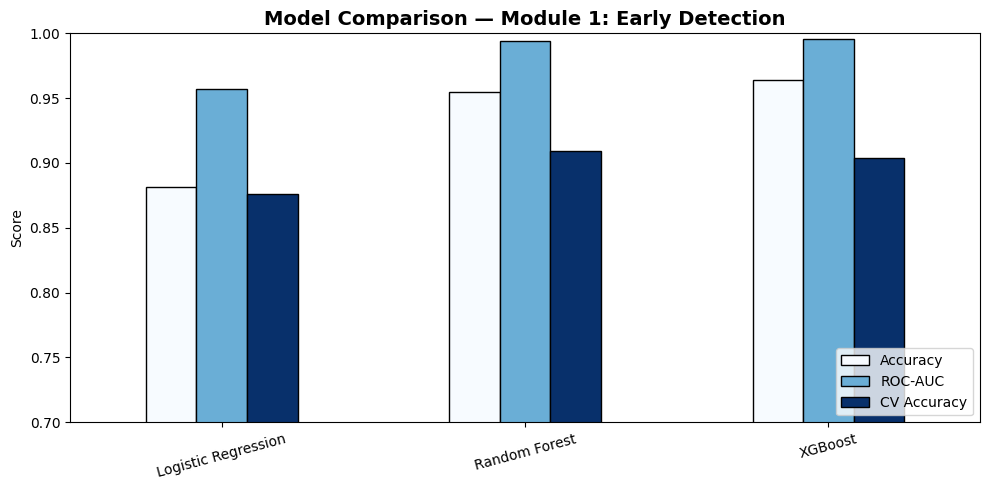


📊 Best Model: XGBoost → AUC: 0.9954


In [59]:
results_df = pd.DataFrame(results).T

results_df.plot(kind='bar', figsize=(10,5), colormap='Blues', edgecolor='black')
plt.title('Model Comparison — Module 1: Early Detection',
          fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison_m1.png', dpi=150)
plt.show()

best_model = results_df['ROC-AUC'].idxmax()
best_score = round(results_df['ROC-AUC'].max(), 4)
print(f"\n📊 Best Model: {best_model} → AUC: {best_score}")

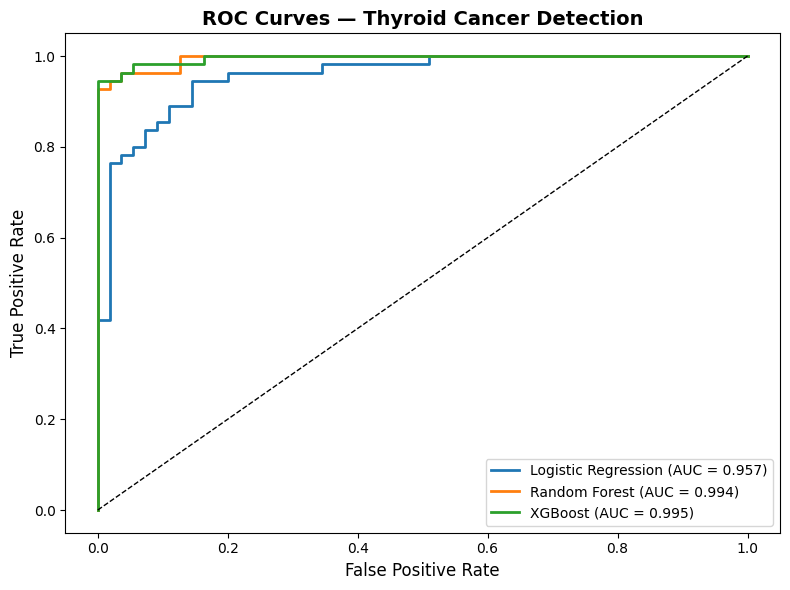

✅ ROC curves done!


In [60]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Thyroid Cancer Detection',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves_m1.png', dpi=150)
plt.show()
print("✅ ROC curves done!")

<Figure size 600x500 with 0 Axes>

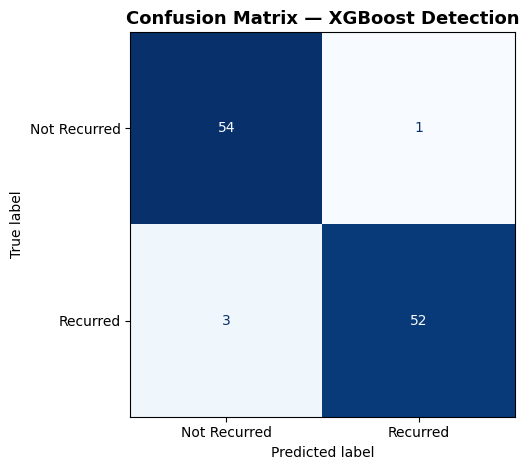

✅ Confusion matrix done!


In [61]:
y_pred_best = models['XGBoost'].predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Recurred', 'Recurred'])

plt.figure(figsize=(6,5))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — XGBoost Detection',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_m1.png', dpi=150)
plt.show()
print("✅ Confusion matrix done!")

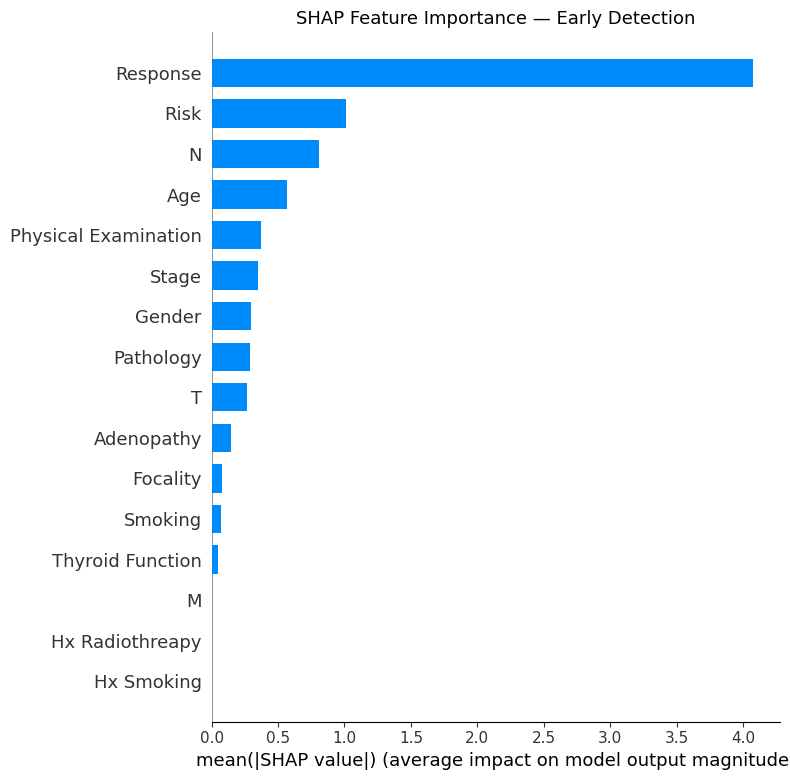

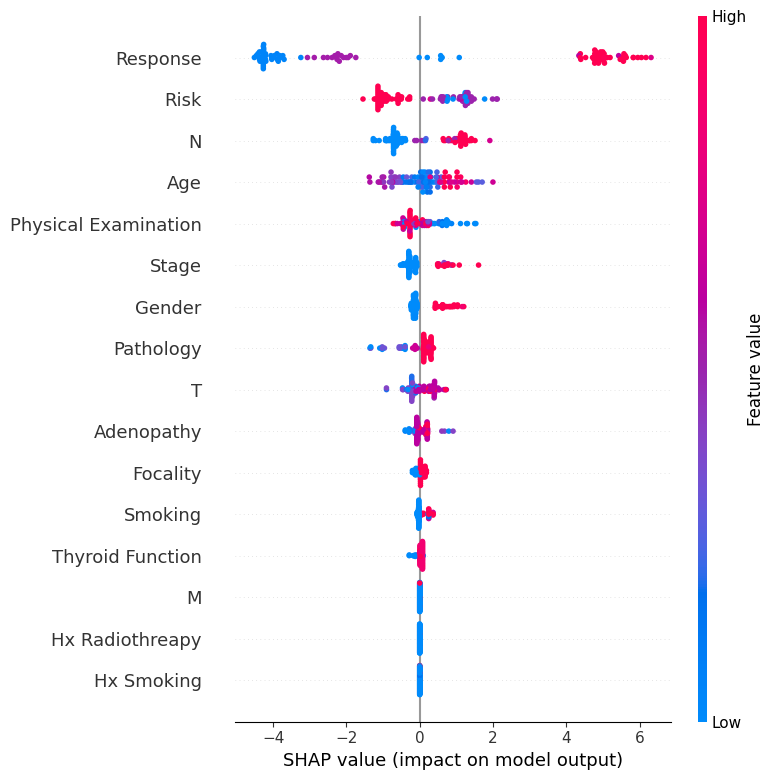

✅ SHAP done!


In [62]:
explainer = shap.Explainer(models['XGBoost'], X_train)
shap_values = explainer(X_test)

# Bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Early Detection", fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar_m1.png', dpi=150)
plt.show()

# Beeswarm plot
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm_m1.png', dpi=150)
plt.show()

print("✅ SHAP done!")

In [63]:
joblib.dump(models['XGBoost'], 'module1_detection_model.pkl')
joblib.dump(scaler, 'module1_scaler.pkl')

print("✅ Module 1 complete and saved!")
print("Files saved: module1_detection_model.pkl, module1_scaler.pkl")

✅ Module 1 complete and saved!
Files saved: module1_detection_model.pkl, module1_scaler.pkl


 Module 2 — Stage Classification (I / II / III / IV)

In [64]:
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import shap, joblib

print("✅ Libraries ready!")

✅ Libraries ready!


In [65]:
# Reload fresh copy of dataset
from google.colab import files
uploaded2 = files.upload()  # Upload Thyroid_Diff.csv again

import io, pandas as pd
filename2 = list(uploaded2.keys())[0]
df2 = pd.read_csv(io.BytesIO(uploaded2[filename2]))

print("✅ Loaded!")
print("Unique Stages:", df2['Stage'].unique())
print("\nStage Distribution:\n", df2['Stage'].value_counts())

Saving Thyroid_Diff.csv to Thyroid_Diff (7).csv
✅ Loaded!
Unique Stages: ['I' 'II' 'IVB' 'III' 'IVA']

Stage Distribution:
 Stage
I      333
II      32
IVB     11
III      4
IVA      3
Name: count, dtype: int64


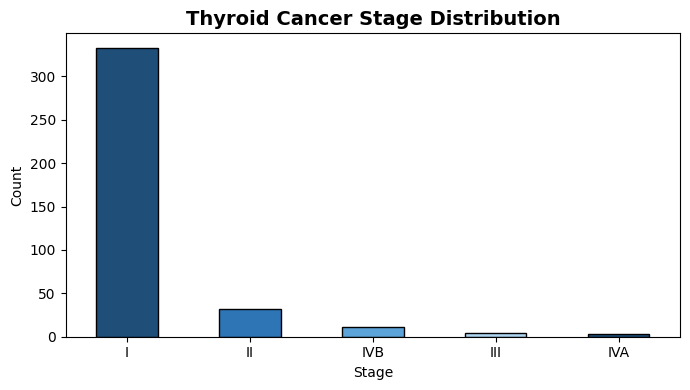

✅ Stage distribution plotted!


In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
df2['Stage'].value_counts().plot(kind='bar',
    color=['#1F4E79','#2E75B6','#5BA3D9','#AED6F1'], edgecolor='black')
plt.title('Thyroid Cancer Stage Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Stage')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('stage_distribution.png', dpi=150)
plt.show()
print("✅ Stage distribution plotted!")

In [67]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import numpy as np

data2 = df2.copy()

# Encode target (Stage) separately to keep label mapping
stage_encoder = LabelEncoder()
data2['Stage_encoded'] = stage_encoder.fit_transform(data2['Stage'])

print("Stage label mapping:")
for i, label in enumerate(stage_encoder.classes_):
    print(f"  {i} → {label}")

# Encode all other categorical columns
le2 = LabelEncoder()
categorical_cols2 = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
                     'Thyroid Function', 'Physical Examination', 'Adenopathy',
                     'Pathology', 'Focality', 'Risk', 'T', 'N', 'M',
                     'Response', 'Recurred']

for col in categorical_cols2:
    data2[col] = le2.fit_transform(data2[col].astype(str))

# Features and target
X2 = data2.drop(['Stage', 'Stage_encoded'], axis=1)
y2 = data2['Stage_encoded']

# Scale
scaler2 = MinMaxScaler()
X2_scaled = pd.DataFrame(scaler2.fit_transform(X2), columns=X2.columns)

# SMOTE for multi-class
smote2 = SMOTE(random_state=42, k_neighbors=2) # Changed k_neighbors from default (5) to 2
X2_res, y2_res = smote2.fit_resample(X2_scaled, y2)

print(f"\nBefore SMOTE: {y2.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y2_res).value_counts().to_dict()}")

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_res, y2_res, test_size=0.2, random_state=42, stratify=y2_res)

print(f"\n✅ Train: {X2_train.shape}, Test: {X2_test.shape}")

Stage label mapping:
  0 → I
  1 → II
  2 → III
  3 → IVA
  4 → IVB

Before SMOTE: {0: 333, 1: 32, 4: 11, 2: 4, 3: 3}
After SMOTE:  {0: 333, 1: 333, 4: 333, 2: 333, 3: 333}

✅ Train: (1332, 16), Test: (333, 16)


In [68]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report

models2 = {
    "Random Forest":  RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":        XGBClassifier(n_estimators=100, random_state=42,
                                     eval_metric='mlogloss'),
    "LightGBM":       LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    "Gradient Boost": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results2 = {}

for name, model in models2.items():
    model.fit(X2_train, y2_train)
    y_pred2 = model.predict(X2_test)

    acc = accuracy_score(y2_test, y_pred2)
    cv  = cross_val_score(model, X2_res, y2_res,
                          cv=StratifiedKFold(5), scoring='accuracy').mean()

    results2[name] = {'Accuracy': acc, 'CV Accuracy': cv}

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  CV Accuracy: {cv:.4f}")
    print(classification_report(y2_test, y_pred2,
                                target_names=stage_encoder.classes_))

print("\n✅ All staging models trained!")


Model: Random Forest
  Accuracy:    0.9880
  CV Accuracy: 0.9790
              precision    recall  f1-score   support

           I       0.98      0.97      0.98        67
          II       0.96      0.98      0.97        66
         III       1.00      0.99      0.99        67
         IVA       1.00      1.00      1.00        67
         IVB       1.00      1.00      1.00        66

    accuracy                           0.99       333
   macro avg       0.99      0.99      0.99       333
weighted avg       0.99      0.99      0.99       333


Model: XGBoost
  Accuracy:    0.9940
  CV Accuracy: 0.9694
              precision    recall  f1-score   support

           I       1.00      0.99      0.99        67
          II       0.99      1.00      0.99        66
         III       1.00      1.00      1.00        67
         IVA       0.99      1.00      0.99        67
         IVB       1.00      0.98      0.99        66

    accuracy                           0.99       333
   ma

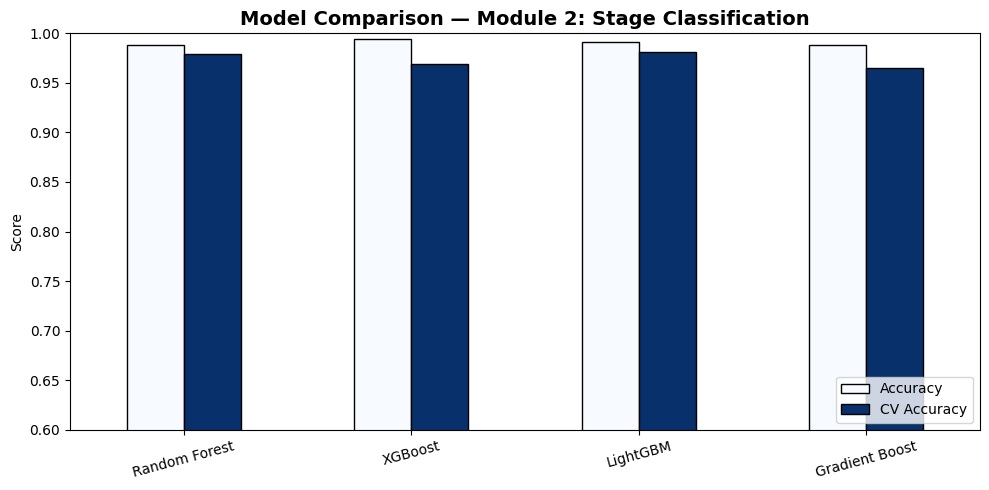


📊 Best Model: XGBoost → Accuracy: 0.994


In [69]:
import pandas as pd

results2_df = pd.DataFrame(results2).T

results2_df.plot(kind='bar', figsize=(10,5), colormap='Blues', edgecolor='black')
plt.title('Model Comparison — Module 2: Stage Classification',
          fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.6, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('staging_model_comparison.png', dpi=150)
plt.show()

best2 = results2_df['Accuracy'].idxmax()
best2_score = round(results2_df['Accuracy'].max(), 4)
print(f"\n📊 Best Model: {best2} → Accuracy: {best2_score}")

<Figure size 800x600 with 0 Axes>

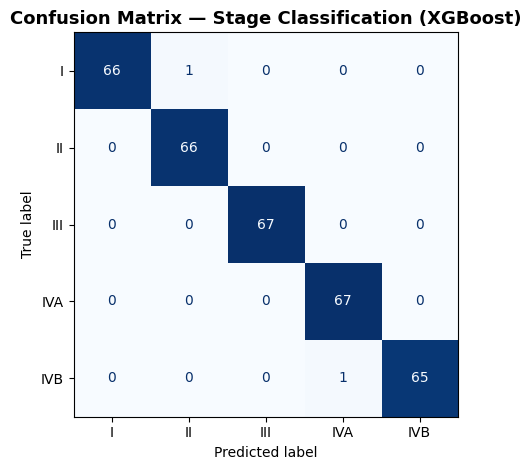

✅ Confusion matrix done!


In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_xgb2 = models2['XGBoost'].predict(X2_test)
cm2 = confusion_matrix(y2_test, y_pred_xgb2)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2,
                                display_labels=stage_encoder.classes_)

plt.figure(figsize=(8,6))
disp2.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Stage Classification (XGBoost)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('staging_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix done!")

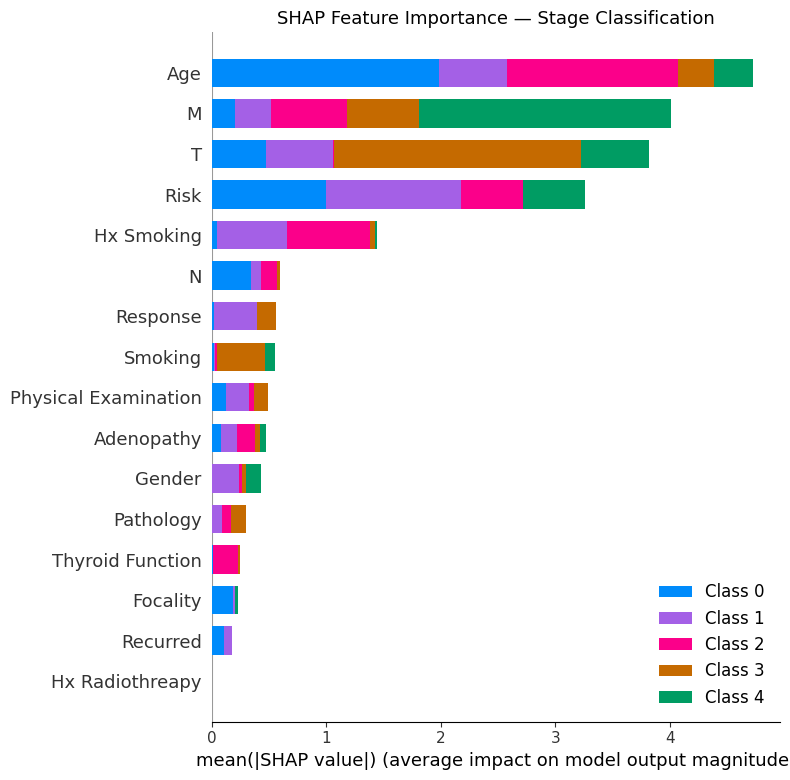

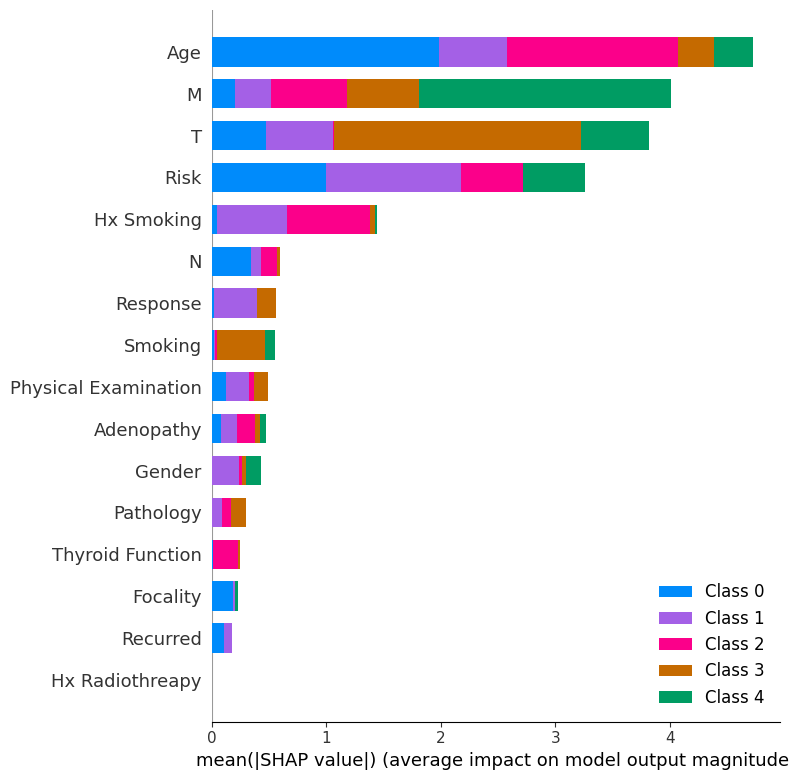

✅ SHAP done!


In [71]:
import shap

explainer2 = shap.Explainer(models2['XGBoost'], X2_train)
shap_values2 = explainer2(X2_test)

# Bar plot
shap.summary_plot(shap_values2, X2_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Stage Classification", fontsize=13)
plt.tight_layout()
plt.savefig('staging_shap_bar.png', dpi=150)
plt.show()

# Beeswarm
shap.summary_plot(shap_values2, X2_test, show=False)
plt.tight_layout()
plt.savefig('staging_shap_beeswarm.png', dpi=150)
plt.show()

print("✅ SHAP done!")

In [72]:
import joblib

joblib.dump(models2['XGBoost'], 'module2_staging_model.pkl')
joblib.dump(scaler2, 'module2_scaler.pkl')
joblib.dump(stage_encoder, 'module2_label_encoder.pkl')

print("✅ Module 2 complete and saved!")
print("Files saved:")
print("  → module2_staging_model.pkl")
print("  → module2_scaler.pkl")
print("  → module2_label_encoder.pkl")

✅ Module 2 complete and saved!
Files saved:
  → module2_staging_model.pkl
  → module2_scaler.pkl
  → module2_label_encoder.pkl


Module 3 — Metastasis Prediction (M: Yes/No)

In [73]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import shap, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries ready!")

✅ Libraries ready!


In [74]:
from google.colab import files
uploaded3 = files.upload()  # Upload Thyroid_Diff.csv again

import io
filename3 = list(uploaded3.keys())[0]
df3 = pd.read_csv(io.BytesIO(uploaded3[filename3]))

print("✅ Loaded!")
print("Unique M values:", df3['M'].unique())
print("\nM Distribution:\n", df3['M'].value_counts())

Saving Thyroid_Diff.csv to Thyroid_Diff (8).csv
✅ Loaded!
Unique M values: ['M0' 'M1']

M Distribution:
 M
M0    365
M1     18
Name: count, dtype: int64


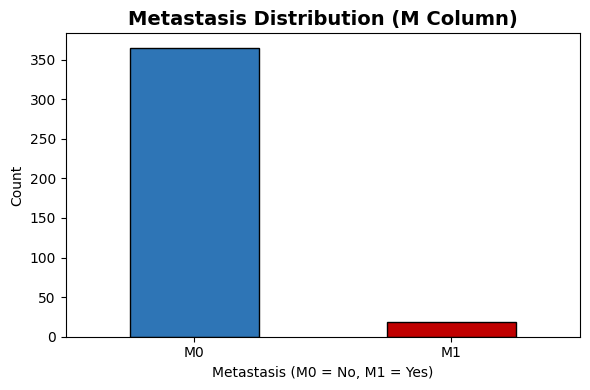

✅ Distribution plotted!


In [75]:
plt.figure(figsize=(6,4))
df3['M'].value_counts().plot(kind='bar',
    color=['#2E75B6','#C00000'], edgecolor='black')
plt.title('Metastasis Distribution (M Column)',
          fontsize=14, fontweight='bold')
plt.xlabel('Metastasis (M0 = No, M1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('metastasis_distribution.png', dpi=150)
plt.show()
print("✅ Distribution plotted!")

In [76]:
data3 = df3.copy()

# Encode target (M) separately
m_encoder = LabelEncoder()
data3['M_encoded'] = m_encoder.fit_transform(data3['M'].astype(str))

print("M label mapping:")
for i, label in enumerate(m_encoder.classes_):
    print(f"  {i} → {label}")

# Encode all other categorical columns
le3 = LabelEncoder()
categorical_cols3 = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
                     'Thyroid Function', 'Physical Examination', 'Adenopathy',
                     'Pathology', 'Focality', 'Risk', 'T', 'N',
                     'Stage', 'Response', 'Recurred']

for col in categorical_cols3:
    data3[col] = le3.fit_transform(data3[col].astype(str))

# Features and target
X3 = data3.drop(['M', 'M_encoded'], axis=1)
y3 = data3['M_encoded']

# Scale
scaler3 = MinMaxScaler()
X3_scaled = pd.DataFrame(scaler3.fit_transform(X3), columns=X3.columns)

# SMOTE
smote3 = SMOTE(random_state=42)
X3_res, y3_res = smote3.fit_resample(X3_scaled, y3)

print(f"\nBefore SMOTE: {y3.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y3_res).value_counts().to_dict()}")

# Split
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3_res, y3_res, test_size=0.2, random_state=42, stratify=y3_res)

print(f"\n✅ Train: {X3_train.shape}, Test: {X3_test.shape}")

M label mapping:
  0 → M0
  1 → M1

Before SMOTE: {0: 365, 1: 18}
After SMOTE:  {0: 365, 1: 365}

✅ Train: (584, 16), Test: (146, 16)


In [77]:
models3 = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric='logloss'),
    "LightGBM":            LGBMClassifier(n_estimators=100, random_state=42,
                                           verbose=-1)
}

results3 = {}

for name, model in models3.items():
    model.fit(X3_train, y3_train)
    y_pred3 = model.predict(X3_test)
    y_prob3 = model.predict_proba(X3_test)[:, 1]

    acc = accuracy_score(y3_test, y_pred3)
    auc = roc_auc_score(y3_test, y_prob3)
    cv  = cross_val_score(model, X3_res, y3_res,
                          cv=StratifiedKFold(5), scoring='accuracy').mean()

    results3[name] = {'Accuracy': acc, 'ROC-AUC': auc, 'CV Accuracy': cv}

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  ROC-AUC:     {auc:.4f}")
    print(f"  CV Accuracy: {cv:.4f}")
    print(classification_report(y3_test, y_pred3,
                                target_names=m_encoder.classes_))

print("\n✅ All metastasis models trained!")


Model: Logistic Regression
  Accuracy:    0.9452
  ROC-AUC:     0.9810
  CV Accuracy: 0.9192
              precision    recall  f1-score   support

          M0       0.99      0.90      0.94        73
          M1       0.91      0.99      0.95        73

    accuracy                           0.95       146
   macro avg       0.95      0.95      0.95       146
weighted avg       0.95      0.95      0.95       146


Model: Random Forest
  Accuracy:    0.9726
  ROC-AUC:     0.9992
  CV Accuracy: 0.9644
              precision    recall  f1-score   support

          M0       0.99      0.96      0.97        73
          M1       0.96      0.99      0.97        73

    accuracy                           0.97       146
   macro avg       0.97      0.97      0.97       146
weighted avg       0.97      0.97      0.97       146


Model: XGBoost
  Accuracy:    0.9795
  ROC-AUC:     0.9996
  CV Accuracy: 0.9219
              precision    recall  f1-score   support

          M0       0.99    

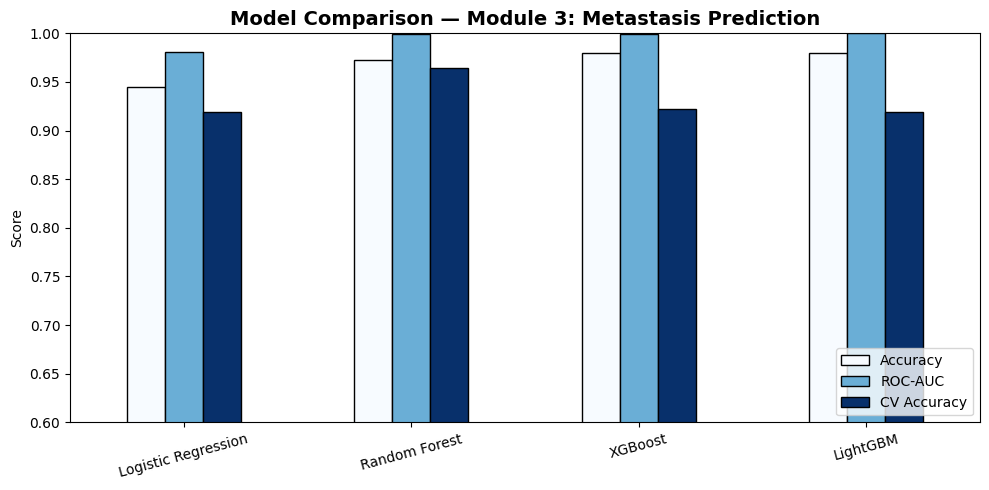


📊 Best Model: LightGBM → AUC: 1.0


In [78]:
results3_df = pd.DataFrame(results3).T

results3_df.plot(kind='bar', figsize=(10,5), colormap='Blues', edgecolor='black')
plt.title('Model Comparison — Module 3: Metastasis Prediction',
          fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.6, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('metastasis_model_comparison.png', dpi=150)
plt.show()

best3 = results3_df['ROC-AUC'].idxmax()
best3_score = round(results3_df['ROC-AUC'].max(), 4)
print(f"\n📊 Best Model: {best3} → AUC: {best3_score}")

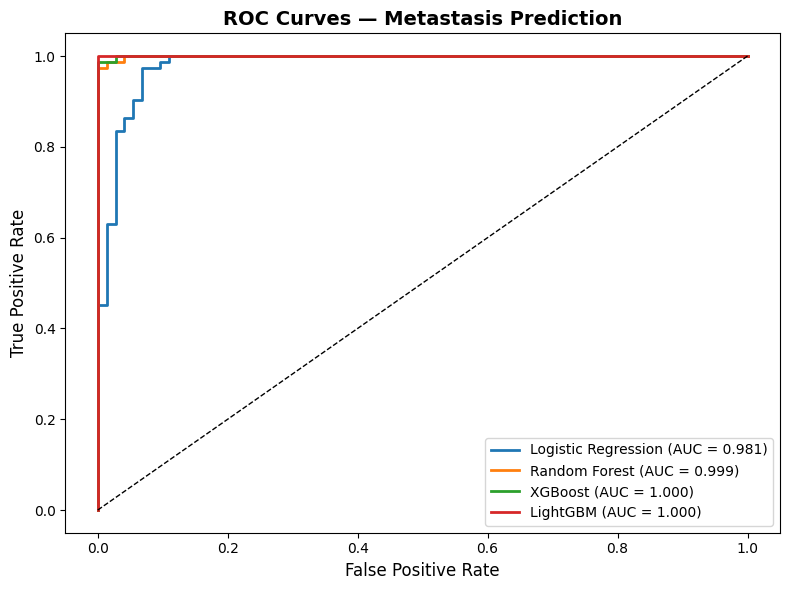

✅ ROC curves done!


In [79]:
plt.figure(figsize=(8,6))

for name, model in models3.items():
    y_prob3 = model.predict_proba(X3_test)[:, 1]
    fpr, tpr, _ = roc_curve(y3_test, y_prob3)
    auc = roc_auc_score(y3_test, y_prob3)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Metastasis Prediction',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('metastasis_roc_curves.png', dpi=150)
plt.show()
print("✅ ROC curves done!")

<Figure size 600x500 with 0 Axes>

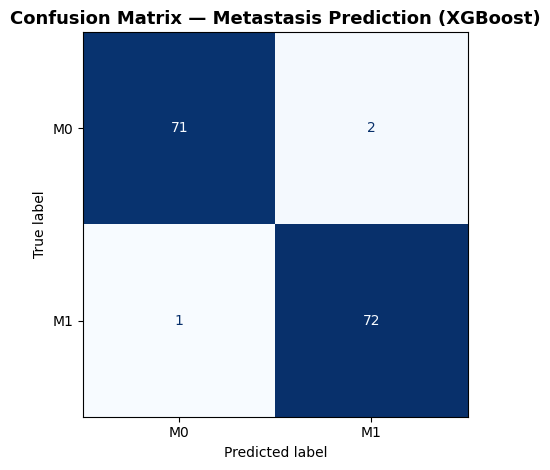

✅ Confusion matrix done!


In [80]:
y_pred_best3 = models3['XGBoost'].predict(X3_test)
cm3 = confusion_matrix(y3_test, y_pred_best3)

disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3,
                                display_labels=m_encoder.classes_)

plt.figure(figsize=(6,5))
disp3.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Metastasis Prediction (XGBoost)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('metastasis_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix done!")

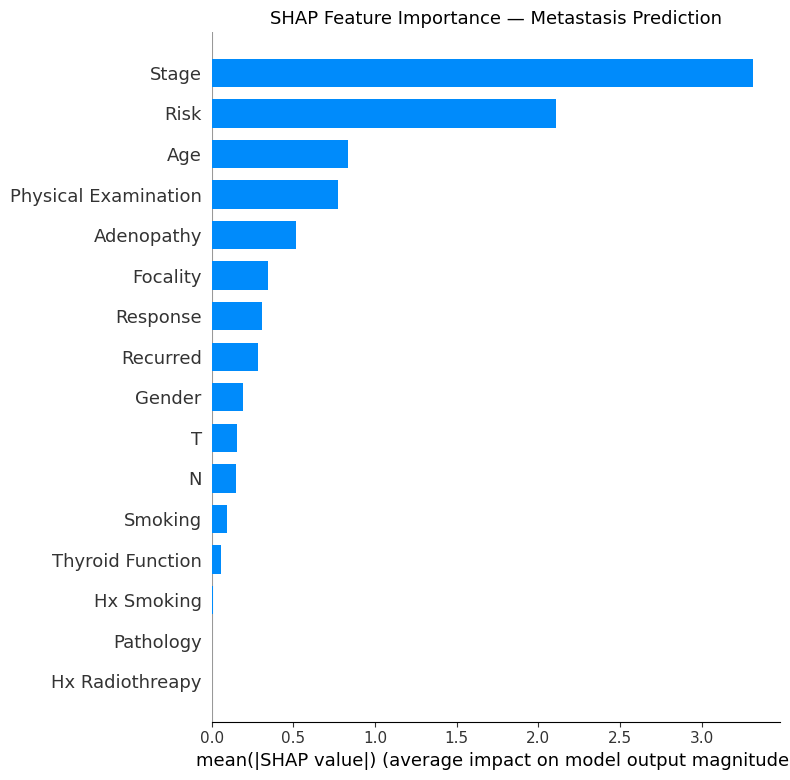

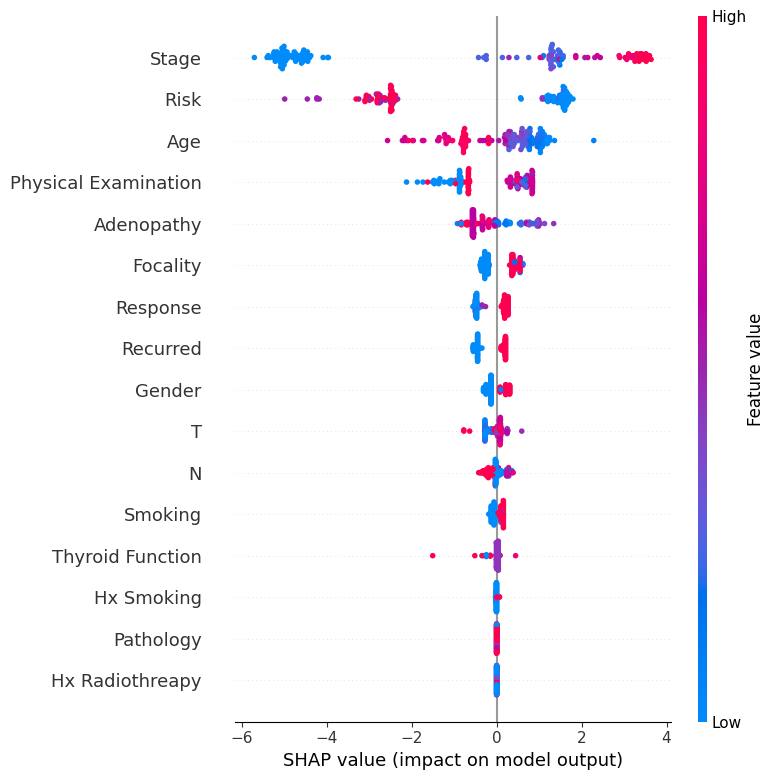

✅ SHAP done!


In [81]:
explainer3 = shap.Explainer(models3['XGBoost'], X3_train)
shap_values3 = explainer3(X3_test)

# Bar plot
shap.summary_plot(shap_values3, X3_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Metastasis Prediction", fontsize=13)
plt.tight_layout()
plt.savefig('metastasis_shap_bar.png', dpi=150)
plt.show()

# Beeswarm
shap.summary_plot(shap_values3, X3_test, show=False)
plt.tight_layout()
plt.savefig('metastasis_shap_beeswarm.png', dpi=150)
plt.show()

print("✅ SHAP done!")

In [82]:
joblib.dump(models3['XGBoost'], 'module3_metastasis_model.pkl')
joblib.dump(scaler3, 'module3_scaler.pkl')
joblib.dump(m_encoder, 'module3_label_encoder.pkl')

print("✅ Module 3 complete and saved!")
print("Files saved:")
print("  → module3_metastasis_model.pkl")
print("  → module3_scaler.pkl")
print("  → module3_label_encoder.pkl")

✅ Module 3 complete and saved!
Files saved:
  → module3_metastasis_model.pkl
  → module3_scaler.pkl
  → module3_label_encoder.pkl


Module 4 — Survival Prognosis (Will Cancer Recur & When?)

In [83]:
!pip install scikit-survival -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

print("✅ All survival libraries imported!")

✅ All survival libraries imported!


In [84]:
from google.colab import files
uploaded4 = files.upload()  # Upload Thyroid_Diff.csv again

import io
filename4 = list(uploaded4.keys())[0]
df4 = pd.read_csv(io.BytesIO(uploaded4[filename4]))

print("✅ Loaded!")
print("Shape:", df4.shape)
print("\nColumns:", df4.columns.tolist())
df4.head()

Saving Thyroid_Diff.csv to Thyroid_Diff (9).csv
✅ Loaded!
Shape: (383, 17)

Columns: ['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


Recurred Distribution:
 Recurred
No     275
Yes    108
Name: count, dtype: int64

Age Stats:
 count    383.000000
mean      40.866841
std       15.134494
min       15.000000
25%       29.000000
50%       37.000000
75%       51.000000
max       82.000000
Name: Age, dtype: float64


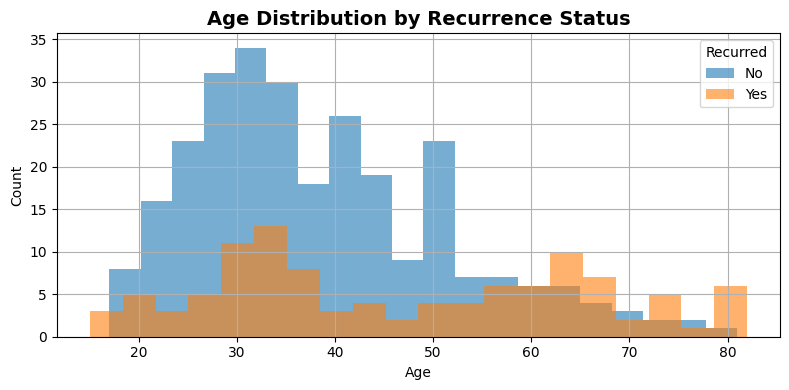

✅ Survival target understood!


In [85]:
# In this dataset:
# 'Recurred' = event (True = cancer recurred, False = did not)
# 'Age'      = used as time proxy (no explicit follow-up time column)

print("Recurred Distribution:\n", df4['Recurred'].value_counts())
print("\nAge Stats:\n", df4['Age'].describe())

# Visualize Age distribution by Recurrence
plt.figure(figsize=(8,4))
for label, group in df4.groupby('Recurred'):
    group['Age'].hist(alpha=0.6, label=label, bins=20)
plt.title('Age Distribution by Recurrence Status',
          fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Recurred')
plt.tight_layout()
plt.savefig('survival_age_distribution.png', dpi=150)
plt.show()
print("✅ Survival target understood!")

In [86]:
data4 = df4.copy()

# Encode all categorical columns
le4 = LabelEncoder()
categorical_cols4 = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
                     'Thyroid Function', 'Physical Examination', 'Adenopathy',
                     'Pathology', 'Focality', 'Risk', 'T', 'N', 'M',
                     'Stage', 'Response']

for col in categorical_cols4:
    data4[col] = le4.fit_transform(data4[col].astype(str))

# Encode Recurred as boolean (required by scikit-survival)
data4['Recurred_bool'] = data4['Recurred'].map({'Yes': True, 'No': False})

print("Recurred bool check:\n", data4['Recurred_bool'].value_counts())

# Features
feature_cols = ['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
                'Thyroid Function', 'Physical Examination', 'Adenopathy',
                'Pathology', 'Focality', 'Risk', 'T', 'N', 'M',
                'Stage', 'Response']

X4 = data4[feature_cols]

# Scale features
scaler4 = MinMaxScaler()
X4_scaled = pd.DataFrame(scaler4.fit_transform(X4), columns=X4.columns)

# Create survival target (event, time)
# Using Age as time proxy since no follow-up time column exists
y4 = Surv.from_arrays(
    event=data4['Recurred_bool'].values,
    time=data4['Age'].values
)

print(f"\n✅ Features shape: {X4_scaled.shape}")
print(f"✅ Survival target created!")

# Train-test split
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4_scaled, y4, test_size=0.2, random_state=42)

print(f"\nTrain: {X4_train.shape}, Test: {X4_test.shape}")

Recurred bool check:
 Recurred_bool
False    275
True     108
Name: count, dtype: int64

✅ Features shape: (383, 16)
✅ Survival target created!

Train: (306, 16), Test: (77, 16)


In [87]:
# Cox Proportional Hazards Model
cox_model = CoxPHSurvivalAnalysis(alpha=0.1)
cox_model.fit(X4_train, y4_train)

# C-Index (like AUC for survival)
cox_pred = cox_model.predict(X4_test)
cox_cindex = concordance_index_censored(
    [y[0] for y in y4_test],
    [y[1] for y in y4_test],
    cox_pred
)[0]

print(f"✅ Cox Model trained!")
print(f"   C-Index: {cox_cindex:.4f}")
print("   (C-Index > 0.7 is good, > 0.8 is excellent)")

✅ Cox Model trained!
   C-Index: 0.9906
   (C-Index > 0.7 is good, > 0.8 is excellent)


In [88]:
# Random Survival Forest
rsf_model = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rsf_model.fit(X4_train, y4_train)

# C-Index
rsf_pred = rsf_model.predict(X4_test)
rsf_cindex = concordance_index_censored(
    [y[0] for y in y4_test],
    [y[1] for y in y4_test],
    rsf_pred
)[0]

print(f"✅ Random Survival Forest trained!")
print(f"   C-Index: {rsf_cindex:.4f}")

✅ Random Survival Forest trained!
   C-Index: 0.9435



📊 Model Comparison:
                         C-Index
Cox PH Model            0.990581
Random Survival Forest  0.943485


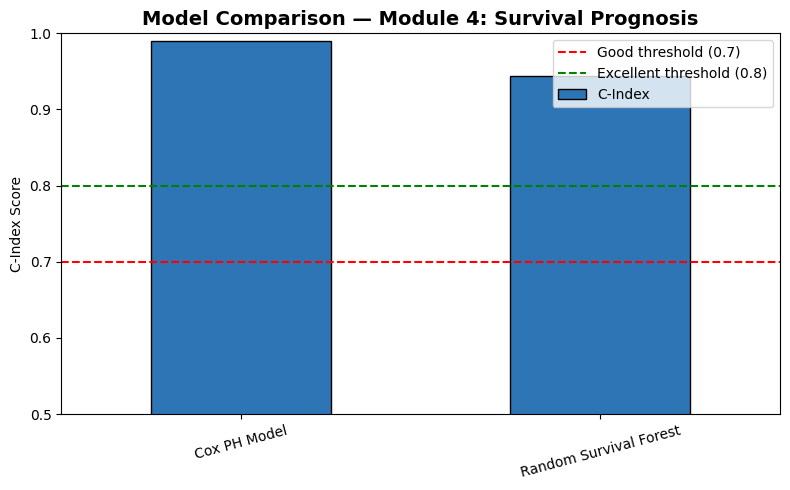


📊 Best Model: Cox PH Model → C-Index: 0.9906


In [89]:
results4 = {
    'Cox PH Model':           {'C-Index': cox_cindex},
    'Random Survival Forest': {'C-Index': rsf_cindex}
}

results4_df = pd.DataFrame(results4).T
print("\n📊 Model Comparison:")
print(results4_df)

# Plot
results4_df.plot(kind='bar', figsize=(8,5),
                  color=['#2E75B6'], edgecolor='black', legend=False)
plt.title('Model Comparison — Module 4: Survival Prognosis',
          fontsize=14, fontweight='bold')
plt.ylabel('C-Index Score')
plt.xticks(rotation=15)
plt.ylim(0.5, 1.0)
plt.axhline(y=0.7, color='red', linestyle='--', label='Good threshold (0.7)')
plt.axhline(y=0.8, color='green', linestyle='--', label='Excellent threshold (0.8)')
plt.legend()
plt.tight_layout()
plt.savefig('survival_model_comparison.png', dpi=150)
plt.show()

best4 = results4_df['C-Index'].idxmax()
print(f"\n📊 Best Model: {best4} → C-Index: {round(results4_df['C-Index'].max(), 4)}")

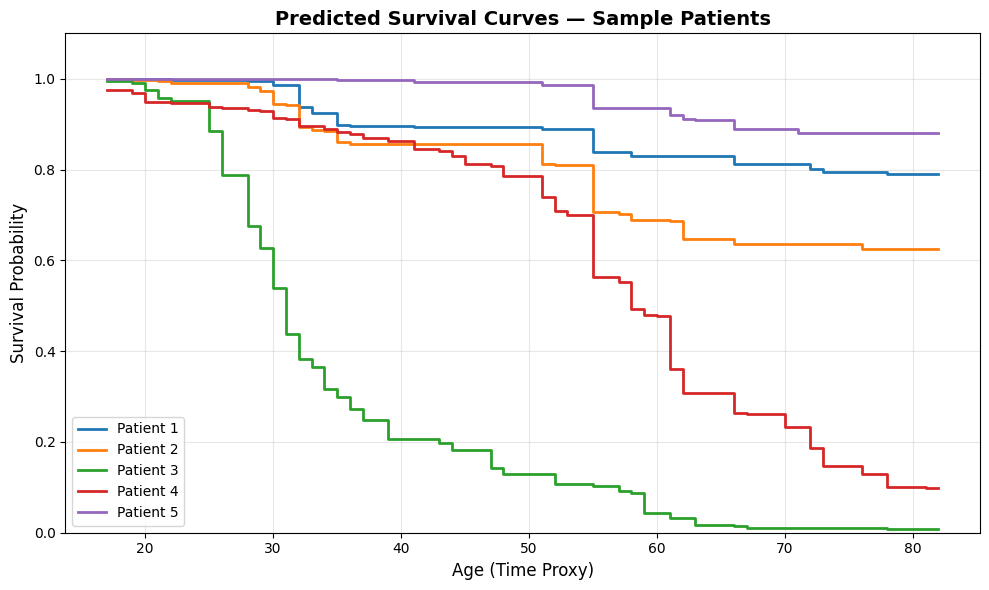

✅ Survival curves plotted!


In [90]:
# Plot survival curves for first 5 test patients
surv_funcs = rsf_model.predict_survival_function(X4_test.iloc[:5])

plt.figure(figsize=(10,6))
for i, fn in enumerate(surv_funcs):
    plt.step(fn.x, fn(fn.x),
             label=f"Patient {i+1}", linewidth=2)

plt.xlabel('Age (Time Proxy)', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.title('Predicted Survival Curves — Sample Patients',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left')
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('survival_curves.png', dpi=150)
plt.show()
print("✅ Survival curves plotted!")

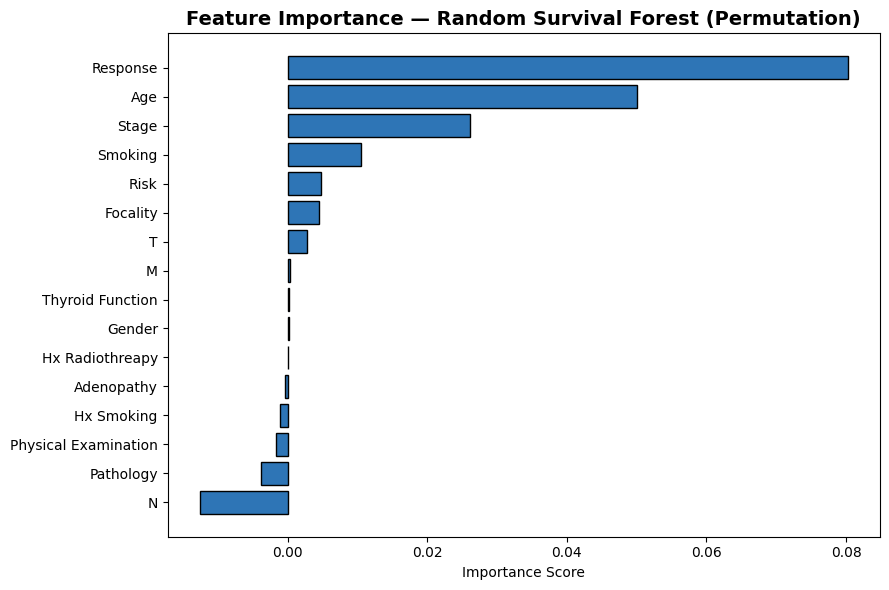

✅ Feature importance plotted!


In [91]:
# Feature importance from Random Survival Forest

# Define a custom scorer for permutation importance using concordance_index_censored
def cindex_scorer(estimator, X, y):
    risk_scores = estimator.predict(X)
    event_indicator = y['event']
    event_time = y['time']
    # concordance_index_censored returns (cindex, concordant, discordant, tied_risk, tied_time)
    # We only need the cindex
    return concordance_index_censored(event_indicator, event_time, risk_scores)[0]

# Calculate permutation importance
perm_importance = permutation_importance(rsf_model, X4_test, y4_test,
                                         scoring=cindex_scorer, n_repeats=10, random_state=42, n_jobs=-1)
importances = perm_importance.importances_mean

feat_imp_df = pd.DataFrame({
    'Feature': X4_test.columns, # Use columns from X4_test which matches the input to permutation_importance
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9,6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
         color='#2E75B6', edgecolor='black')
plt.title('Feature Importance — Random Survival Forest (Permutation)',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('survival_feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance plotted!")

✅ New Patient Prediction:
   Risk Score: 17.6104
   (Higher score = Higher recurrence risk)


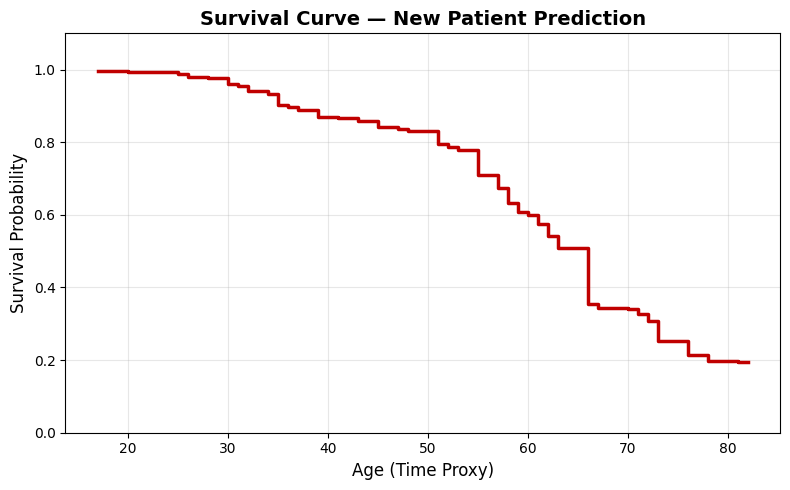

In [92]:
# Example: Predict survival probability for a new patient
import numpy as np

# Sample new patient (use same feature order)
new_patient = pd.DataFrame([{
    'Age': 45,
    'Gender': 1,           # 1 = Male, 0 = Female
    'Smoking': 0,
    'Hx Smoking': 0,
    'Hx Radiothreapy': 0,
    'Thyroid Function': 2,
    'Physical Examination': 1,
    'Adenopathy': 0,
    'Pathology': 1,
    'Focality': 0,
    'Risk': 1,
    'T': 2,
    'N': 0,
    'M': 0,
    'Stage': 1,
    'Response': 2
}])

# Scale using same scaler
new_patient_scaled = pd.DataFrame(
    scaler4.transform(new_patient),
    columns=new_patient.columns
)

# Predict
risk_score = rsf_model.predict(new_patient_scaled)[0]
surv_fn = rsf_model.predict_survival_function(new_patient_scaled)[0]

print(f"✅ New Patient Prediction:")
print(f"   Risk Score: {risk_score:.4f}")
print(f"   (Higher score = Higher recurrence risk)")

# Plot survival curve for this patient
plt.figure(figsize=(8,5))
plt.step(surv_fn.x, surv_fn(surv_fn.x),
         color='#C00000', linewidth=2.5)
plt.xlabel('Age (Time Proxy)', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.title('Survival Curve — New Patient Prediction',
          fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('new_patient_survival.png', dpi=150)
plt.show()

In [93]:
joblib.dump(rsf_model,  'module4_rsf_model.pkl')
joblib.dump(cox_model,  'module4_cox_model.pkl')
joblib.dump(scaler4,    'module4_scaler.pkl')

print("✅ Module 4 complete and saved!")
print("Files saved:")
print("  → module4_rsf_model.pkl")
print("  → module4_cox_model.pkl")
print("  → module4_scaler.pkl")

✅ Module 4 complete and saved!
Files saved:
  → module4_rsf_model.pkl
  → module4_cox_model.pkl
  → module4_scaler.pkl


Final Integration Pipeline

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sksurv.ensemble import RandomSurvivalForest

print("✅ Libraries ready!")

✅ Libraries ready!


 Load All 4 Saved Models

### Regenerating Module 1 and Module 2 models

The following cells will re-process the data and re-train the models for Module 1 (Early Detection) and Module 2 (Stage Classification) to ensure all `.pkl` files are available for loading in the final integration step.

In [95]:
# Reload the dataset to ensure `df` and `df2` are available
# Assuming Thyroid_Diff.csv is in the content directory from previous uploads
df = pd.read_csv('/content/Thyroid_Diff.csv')
df2 = pd.read_csv('/content/Thyroid_Diff.csv')

print("✅ Datasets reloaded for Module 1 (df) and Module 2 (df2)!")

✅ Datasets reloaded for Module 1 (df) and Module 2 (df2)!


#### Module 1: Early Detection (Recurred: Yes/No)

In [96]:
data = df.copy()

# Encode all categorical columns
le = LabelEncoder()
categorical_cols = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
                    'Thyroid Function', 'Physical Examination', 'Adenopathy',
                    'Pathology', 'Focality', 'Risk', 'T', 'N', 'M',
                    'Stage', 'Response', 'Recurred']

for col in categorical_cols:
    data[col] = le.fit_transform(data[col].astype(str))

# Features and target
X = data.drop('Recurred', axis=1)
y = data['Recurred']

# Scale
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

print("✅ Module 1 Data Preparation and Splitting done!")

✅ Module 1 Data Preparation and Splitting done!


In [97]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    # Only print confirmation for training, full reports were already done earlier
print("✅ Module 1 Models (Logistic Regression, Random Forest, XGBoost) retrained!")

✅ Module 1 Models (Logistic Regression, Random Forest, XGBoost) retrained!


In [98]:
joblib.dump(models['XGBoost'], 'module1_detection_model.pkl')
joblib.dump(scaler, 'module1_scaler.pkl')

print("✅ Module 1 models and scaler re-saved!")

✅ Module 1 models and scaler re-saved!


#### Module 2: Stage Classification (I / II / III / IV)

In [99]:
data2 = df2.copy()

# Encode target (Stage) separately to keep label mapping
stage_encoder = LabelEncoder()
data2['Stage_encoded'] = stage_encoder.fit_transform(data2['Stage'])

# Encode all other categorical columns
le2 = LabelEncoder()
categorical_cols2 = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
                     'Thyroid Function', 'Physical Examination', 'Adenopathy',
                     'Pathology', 'Focality', 'Risk', 'T', 'N', 'M',
                     'Response', 'Recurred']

for col in categorical_cols2:
    data2[col] = le2.fit_transform(data2[col].astype(str))

# Features and target
X2 = data2.drop(['Stage', 'Stage_encoded'], axis=1)
y2 = data2['Stage_encoded']

# Scale
scaler2 = MinMaxScaler()
X2_scaled = pd.DataFrame(scaler2.fit_transform(X2), columns=X2.columns)

# SMOTE for multi-class (using k_neighbors=2 as previously determined)
smote2 = SMOTE(random_state=42, k_neighbors=2)
X2_res, y2_res = smote2.fit_resample(X2_scaled, y2)

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_res, y2_res, test_size=0.2, random_state=42, stratify=y2_res)

print("✅ Module 2 Data Preparation and Splitting done!")

✅ Module 2 Data Preparation and Splitting done!


In [100]:
models2 = {
    "Random Forest":  RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":        XGBClassifier(n_estimators=100, random_state=42,
                                     eval_metric='mlogloss'),
    "LightGBM":       LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    "Gradient Boost": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

for name, model in models2.items():
    model.fit(X2_train, y2_train)
    # Only print confirmation for training, full reports were already done earlier
print("✅ Module 2 Models (Random Forest, XGBoost, LightGBM, Gradient Boost) retrained!")

✅ Module 2 Models (Random Forest, XGBoost, LightGBM, Gradient Boost) retrained!


In [101]:
joblib.dump(models2['XGBoost'], 'module2_staging_model.pkl')
joblib.dump(scaler2, 'module2_scaler.pkl')
joblib.dump(stage_encoder, 'module2_label_encoder.pkl')

print("✅ Module 2 models, scaler, and label encoder re-saved!")

✅ Module 2 models, scaler, and label encoder re-saved!


In [102]:
# Load all models
m1_model   = joblib.load('module1_detection_model.pkl')
m1_scaler  = joblib.load('module1_scaler.pkl')

m2_model   = joblib.load('module2_staging_model.pkl')
m2_scaler  = joblib.load('module2_scaler.pkl')
m2_encoder = joblib.load('module2_label_encoder.pkl')

m3_model   = joblib.load('module3_metastasis_model.pkl')
m3_scaler  = joblib.load('module3_scaler.pkl')
m3_encoder = joblib.load('module3_label_encoder.pkl')

m4_model   = joblib.load('module4_rsf_model.pkl')
m4_scaler  = joblib.load('module4_scaler.pkl')

print("✅ All 4 models loaded successfully!")

✅ All 4 models loaded successfully!


In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sksurv.ensemble import RandomSurvivalForest

print("✅ Libraries ready!")

✅ Libraries ready!


In [104]:
# Load all models
m1_model   = joblib.load('module1_detection_model.pkl')
m1_scaler  = joblib.load('module1_scaler.pkl')

m2_model   = joblib.load('module2_staging_model.pkl')
m2_scaler  = joblib.load('module2_scaler.pkl')
m2_encoder = joblib.load('module2_label_encoder.pkl')

m3_model   = joblib.load('module3_metastasis_model.pkl')
m3_scaler  = joblib.load('module3_scaler.pkl')
m3_encoder = joblib.load('module3_label_encoder.pkl')

m4_model   = joblib.load('module4_rsf_model.pkl')
m4_scaler  = joblib.load('module4_scaler.pkl')

print("✅ All 4 models loaded successfully!")

✅ All 4 models loaded successfully!


In [105]:
# ============================================
# ENTER PATIENT DATA HERE
# ============================================
patient_data = {
    'Age':                  45,
    'Gender':               'F',
    'Smoking':              'No',
    'Hx Smoking':           'No',
    'Hx Radiothreapy':      'No',
    'Thyroid Function':     'Euthyroid',
    'Physical Examination': 'Single nodular goiter-right',
    'Adenopathy':           'No',
    'Pathology':            'Micropapillary',
    'Focality':             'Uni-Focal',
    'Risk':                 'Low',
    'T':                    'T1a',
    'N':                    'N0',
    'M':                    'M0',
    'Stage':                'I',
    'Response':             'Excellent'
}

patient_df = pd.DataFrame([patient_data])
print("✅ Patient data entered!")
print(patient_df)

✅ Patient data entered!
   Age Gender Smoking Hx Smoking Hx Radiothreapy Thyroid Function  \
0   45      F      No         No              No        Euthyroid   

          Physical Examination Adenopathy       Pathology   Focality Risk  \
0  Single nodular goiter-right         No  Micropapillary  Uni-Focal  Low   

     T   N   M Stage   Response  
0  T1a  N0  M0     I  Excellent  


Preprocessing Function

In [106]:
def preprocess_patient(patient_df, scaler, drop_cols=[]):
    """
    Encodes and scales a patient dataframe
    for any of the 4 modules.
    """
    data = patient_df.copy()

    # Drop target columns if present
    for col in drop_cols:
        if col in data.columns:
            data = data.drop(col, axis=1)

    # Encode categorical columns
    le = LabelEncoder()
    for col in data.select_dtypes(include=['object']).columns:
        data[col] = le.fit_transform(data[col].astype(str))

    # Scale
    data_scaled = pd.DataFrame(
        scaler.transform(data),
        columns=data.columns
    )

    return data_scaled

print("✅ Preprocessing function ready!")

✅ Preprocessing function ready!


 Module 1: Detection

In [107]:
# Prepare input for Module 1
# Drop 'Recurred' column (that's what we're predicting)
m1_input = preprocess_patient(
    patient_df.copy(),
    m1_scaler,
    drop_cols=['Recurred']
)

# Predict
m1_pred = m1_model.predict(m1_input)[0]
m1_prob = m1_model.predict_proba(m1_input)[0][1]

m1_result = "YES — Cancer Likely" if m1_pred == 1 else "NO — Cancer Unlikely"

print("=" * 45)
print("🔬 MODULE 1 RESULT — Early Detection")
print("=" * 45)
print(f"  Prediction : {m1_result}")
print(f"  Confidence : {m1_prob*100:.1f}%")

🔬 MODULE 1 RESULT — Early Detection
  Prediction : NO — Cancer Unlikely
  Confidence : 10.4%


Module 2: Stage Classification

In [109]:
m2_patient_df_prepared = patient_df.copy()
# Add the 'Recurred' status from Module 1 prediction, as it is a feature for Module 2
m2_patient_df_prepared['Recurred'] = 'No' if m1_pred == 0 else 'Yes'

# Prepare input for Module 2
# Drop 'Stage' column (that's what we're predicting)
m2_input = preprocess_patient(
    m2_patient_df_prepared,
    m2_scaler,
    drop_cols=['Stage']
)

# Predict
m2_pred       = m2_model.predict(m2_input)[0]
m2_prob       = m2_model.predict_proba(m2_input)[0]
m2_stage      = m2_encoder.inverse_transform([m2_pred])[0]
m2_confidence = max(m2_prob) * 100

print("=" * 45)
print("🔬 MODULE 2 RESULT — Stage Classification")
print("=" * 45)
print(f"  Predicted Stage : {m2_stage}")
print(f"  Confidence      : {m2_confidence:.1f}%")
print(f"  All Probabilities:")
for i, cls in enumerate(m2_encoder.classes_):
    print(f"    Stage {cls}: {m2_prob[i]*100:.1f}%")

🔬 MODULE 2 RESULT — Stage Classification
  Predicted Stage : I
  Confidence      : 99.3%
  All Probabilities:
    Stage I: 99.3%
    Stage II: 0.5%
    Stage III: 0.0%
    Stage IVA: 0.1%
    Stage IVB: 0.1%


 Module 3: Metastasis

In [111]:
# Prepare input for Module 3
# Drop 'M' column (that's what we're predicting)
m3_patient_df_prepared = patient_df.copy()
m3_patient_df_prepared['Recurred'] = 'No' if m1_pred == 0 else 'Yes'

m3_input = preprocess_patient(
    m3_patient_df_prepared,
    m3_scaler,
    drop_cols=['M']
)

# Predict
m3_pred   = m3_model.predict(m3_input)[0]
m3_prob   = m3_model.predict_proba(m3_input)[0][1]
m3_result = m3_encoder.inverse_transform([m3_pred])[0]

print("=" * 45)
print("🔬 MODULE 3 RESULT — Metastasis Prediction")
print("=" * 45)
print(f"  Metastasis Status : {m3_result}")
print(f"  Risk Probability  : {m3_prob*100:.1f}%")

🔬 MODULE 3 RESULT — Metastasis Prediction
  Metastasis Status : M0
  Risk Probability  : 0.6%


Module 4: Survival Prognosis

🔬 MODULE 4 RESULT — Survival Prognosis
  Risk Score : 15.1066
  (Higher = Greater recurrence risk)

  Survival Probabilities:
    At Age 30: 97.0%
    At Age 40: 88.7%
    At Age 50: 85.0%
    At Age 60: 65.6%
    At Age 70: 44.4%


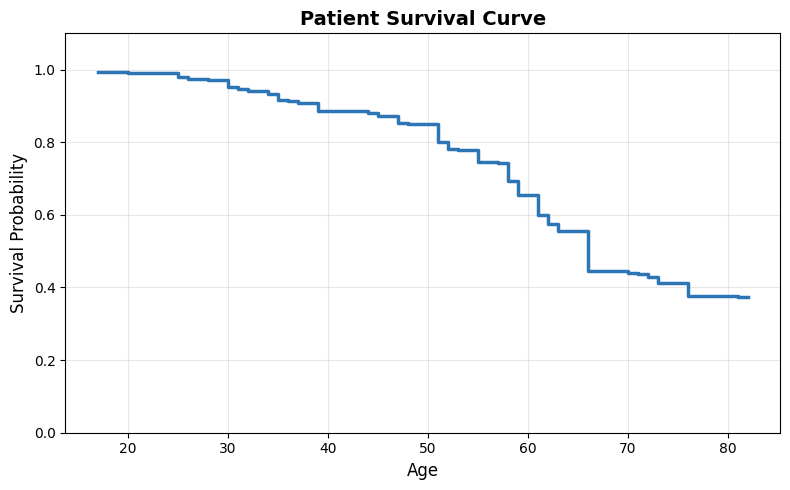

In [112]:
from sksurv.util import Surv

# Prepare input for Module 4
m4_input = preprocess_patient(
    patient_df.copy(),
    m4_scaler,
    drop_cols=['Recurred']
)

# Predict risk score
m4_risk = m4_model.predict(m4_input)[0]

# Predict survival function
surv_fn = m4_model.predict_survival_function(m4_input)[0]

# Survival probability at key age milestones
milestones = [30, 40, 50, 60, 70]
print("=" * 45)
print("🔬 MODULE 4 RESULT — Survival Prognosis")
print("=" * 45)
print(f"  Risk Score : {m4_risk:.4f}")
print(f"  (Higher = Greater recurrence risk)")
print(f"\n  Survival Probabilities:")
for age in milestones:
    try:
        prob = surv_fn(age)
        print(f"    At Age {age}: {prob*100:.1f}%")
    except:
        print(f"    At Age {age}: N/A")

# Plot survival curve
plt.figure(figsize=(8,5))
plt.step(surv_fn.x, surv_fn(surv_fn.x),
         color='#2E75B6', linewidth=2.5)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.title('Patient Survival Curve',
          fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('patient_survival_curve.png', dpi=150)
plt.show()

Full Patient Report

In [113]:
print("\n")
print("=" * 55)
print("       🏥 ThyroAI — FULL PATIENT REPORT")
print("=" * 55)
print(f"  Patient Age    : {patient_data['Age']}")
print(f"  Gender         : {patient_data['Gender']}")
print(f"  Risk Level     : {patient_data['Risk']}")
print("-" * 55)
print(f"  🔍 Detection   : {m1_result}")
print(f"     Confidence  : {m1_prob*100:.1f}%")
print("-" * 55)
print(f"  📊 Stage       : {m2_stage}")
print(f"     Confidence  : {m2_confidence:.1f}%")
print("-" * 55)
print(f"  🔴 Metastasis  : {m3_result}")
print(f"     Risk        : {m3_prob*100:.1f}%")
print("-" * 55)
print(f"  ⏳ Survival    : Risk Score = {m4_risk:.4f}")
print(f"     Prognosis   : {'High Risk' if m4_risk > 0.5 else 'Low Risk'}")
print("=" * 55)
print("  ✅ Report Generated by ThyroAI")
print("=" * 55)



       🏥 ThyroAI — FULL PATIENT REPORT
  Patient Age    : 45
  Gender         : F
  Risk Level     : Low
-------------------------------------------------------
  🔍 Detection   : NO — Cancer Unlikely
     Confidence  : 10.4%
-------------------------------------------------------
  📊 Stage       : I
     Confidence  : 99.3%
-------------------------------------------------------
  🔴 Metastasis  : M0
     Risk        : 0.6%
-------------------------------------------------------
  ⏳ Survival    : Risk Score = 15.1066
     Prognosis   : High Risk
  ✅ Report Generated by ThyroAI


Save Full Report as Text File

In [114]:
report_lines = [
    "=" * 55,
    "       ThyroAI — FULL PATIENT REPORT",
    "=" * 55,
    f"  Patient Age    : {patient_data['Age']}",
    f"  Gender         : {patient_data['Gender']}",
    f"  Risk Level     : {patient_data['Risk']}",
    "-" * 55,
    f"  Detection      : {m1_result}",
    f"  Confidence     : {m1_prob*100:.1f}%",
    "-" * 55,
    f"  Stage          : {m2_stage}",
    f"  Confidence     : {m2_confidence:.1f}%",
    "-" * 55,
    f"  Metastasis     : {m3_result}",
    f"  Risk           : {m3_prob*100:.1f}%",
    "-" * 55,
    f"  Survival Score : {m4_risk:.4f}",
    f"  Prognosis      : {'High Risk' if m4_risk > 0.5 else 'Low Risk'}",
    "=" * 55,
    "  Report Generated by ThyroAI"
]

with open('ThyroAI_Patient_Report.txt', 'w') as f:
    f.write('\n'.join(report_lines))

print("✅ Report saved as: ThyroAI_Patient_Report.txt")

# Download it
from google.colab import files
files.download('ThyroAI_Patient_Report.txt')

✅ Report saved as: ThyroAI_Patient_Report.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [115]:
from google.colab import files
import os

# List of all important files to download
download_files = [
    # Models
    'module1_detection_model.pkl',
    'module2_staging_model.pkl',
    'module3_metastasis_model.pkl',
    'module4_rsf_model.pkl',
    'module4_cox_model.pkl',

    # Scalers & Encoders
    'module1_scaler.pkl',
    'module2_scaler.pkl',
    'module2_label_encoder.pkl',
    'module3_scaler.pkl',
    'module3_label_encoder.pkl',
    'module4_scaler.pkl',

    # Charts & Plots
    'target_distribution.png',
    'model_comparison_m1.png',
    'roc_curves_m1.png',
    'confusion_matrix_m1.png',
    'shap_bar_m1.png',
    'shap_beeswarm_m1.png',
    'stage_distribution.png',
    'staging_model_comparison.png',
    'staging_confusion_matrix.png',
    'staging_shap_bar.png',
    'metastasis_distribution.png',
    'metastasis_model_comparison.png',
    'metastasis_roc_curves.png',
    'metastasis_confusion_matrix.png',
    'metastasis_shap_bar.png',
    'survival_age_distribution.png',
    'survival_model_comparison.png',
    'survival_curves.png',
    'survival_feature_importance.png',
    'patient_survival_curve.png',

    # Report
    'ThyroAI_Patient_Report.txt',
]

print("Downloading all files...")
for file in download_files:
    if os.path.exists(file):
        files.download(file)
        print(f"✅ Downloaded: {file}")
    else:
        print(f"⚠️ Not found: {file}")

print("\n✅ All downloads complete!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: module1_detection_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: patient_survival_curve.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: ThyroAI_Patient_Report.txt

✅ All downloads complete!
